# 07 — Uplift Model Evaluation

## Objective

This notebook evaluates the quality of the T-Learner uplift model developed in Notebook 06.

The objective is to determine whether the model successfully ranks customers according to their expected incremental response to treatment.

Unlike conventional classification metrics, uplift evaluation focuses on the difference between treatment and control outcomes.

### Evaluation Metrics

We will calculate:

- Uplift by customer ranking
- Cumulative incremental conversions
- Qini Curve
- Qini Coefficient
- Area Under the Uplift Curve (AUUC)
- Uplift@10%
- Uplift@20%
- Random targeting benchmark
- Targeting efficiency

The evaluation will determine whether the T-Learner provides useful customer prioritization for treatment allocation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
PREDICTIONS_PATH = Path(
    r"C:\Users\ugand\customer-churn-uplift-modeling\data\processed\t_learner_uplift_predictions.csv"
)

print("File exists:", PREDICTIONS_PATH.exists())

File exists: True


In [3]:
uplift_df = pd.read_csv(
    PREDICTIONS_PATH
)

print("Dataset shape:", uplift_df.shape)

uplift_df.head()

Dataset shape: (20000, 8)


,customer_index,actual_treatment,actual_conversion,predicted_control,predicted_treatment,uplift,uplift_segment,uplift_decile
0,21175,1,0,0.000436,0.014119,0.013683,Positive Uplift,6
1,28968,1,0,0.054692,0.095128,0.040436,Positive Uplift,8
2,78207,0,0,0.276301,0.032204,-0.244096,Negative Uplift,1
3,25183,1,0,0.000686,0.002107,0.001421,Positive Uplift,3
4,97744,0,0,0.000000,0.020826,0.020826,Positive Uplift,6


In [4]:
required_columns = [
    "customer_index",
    "actual_treatment",
    "actual_conversion",
    "predicted_control",
    "predicted_treatment",
    "uplift"
]

missing_columns = [
    col
    for col in required_columns
    if col not in uplift_df.columns
]

print("Missing columns:", missing_columns)

if len(missing_columns) == 0:
    print("All required columns are available.")

Missing columns: []
All required columns are available.


In [5]:
print(
    uplift_df["uplift"].describe()
)

count    20000.000000
mean         0.041975
std          0.079734
min         -0.381696
25%          0.001421
50%          0.010399
75%          0.054337
max          0.747002
Name: uplift, dtype: float64


In [6]:
print(
    uplift_df["actual_treatment"]
    .value_counts()
    .sort_index()
)

print("\nTreatment proportions:")

print(
    uplift_df["actual_treatment"]
    .value_counts(normalize=True)
    .sort_index()
)

actual_treatment
0     3037
1    16963
Name: count, dtype: int64

Treatment proportions:
actual_treatment
0    0.15185
1    0.84815
Name: proportion, dtype: float64


In [7]:
evaluation_conversion = (
    uplift_df
    .groupby("actual_treatment")["actual_conversion"]
    .mean()
)

print("Control conversion rate:")
print(evaluation_conversion.loc[0])

print("\nTreatment conversion rate:")
print(evaluation_conversion.loc[1])

Control conversion rate:
0.001975633849193283

Treatment conversion rate:
0.0037139656900312444


In [8]:
control_conversion = evaluation_conversion.loc[0]
treatment_conversion = evaluation_conversion.loc[1]

observed_ate = (
    treatment_conversion -
    control_conversion
)

print(
    f"Observed treatment effect: {observed_ate:.6f}"
)

Observed treatment effect: 0.001738


In [9]:
uplift_ranked = (
    uplift_df
    .sort_values(
        "uplift",
        ascending=False
    )
    .reset_index(drop=True)
)

uplift_ranked["rank"] = (
    np.arange(len(uplift_ranked)) + 1
)

uplift_ranked["population_fraction"] = (
    uplift_ranked["rank"] /
    len(uplift_ranked)
)

uplift_ranked.head(10)

,customer_index,actual_treatment,actual_conversion,predicted_control,predicted_treatment,uplift,uplift_segment,uplift_decile,rank,population_fraction
0,99343,1,0,0.123074,0.870076,0.747002,Positive Uplift,10,1,0.00005
1,74161,0,0,0.113354,0.811204,0.697850,Positive Uplift,10,2,0.00010
2,58759,1,0,0.052978,0.688561,0.635583,Positive Uplift,10,3,0.00015
3,96475,1,0,0.083911,0.713814,0.629903,Positive Uplift,10,4,0.00020
4,68151,1,0,0.123849,0.753358,0.629509,Positive Uplift,10,5,0.00025
5,31892,1,0,0.078600,0.703329,0.624729,Positive Uplift,10,6,0.00030
6,86056,1,0,0.075880,0.700358,0.624478,Positive Uplift,10,7,0.00035
7,58131,1,0,0.187960,0.809818,0.621858,Positive Uplift,10,8,0.00040
8,66408,1,0,0.162315,0.777227,0.614912,Positive Uplift,10,9,0.00045
9,11654,0,0,0.055588,0.649322,0.593734,Positive Uplift,10,10,0.00050


In [10]:
uplift_ranked["decile"] = pd.qcut(
    uplift_ranked["uplift"],
    q=10,
    labels=False,
    duplicates="drop"
)

uplift_ranked["decile"] = (
    uplift_ranked["decile"] + 1
)

uplift_ranked["decile"].value_counts().sort_index()

decile
1     2579
2     1672
3     2441
4     1616
5     1692
6     2001
7     1999
8     2001
9     1999
10    2000
Name: count, dtype: int64

In [11]:
decile_summary = (
    uplift_ranked
    .groupby("decile")
    .agg(
        customers=("uplift", "size"),
        mean_uplift=("uplift", "mean"),
        mean_predicted_treatment=(
            "predicted_treatment",
            "mean"
        ),
        mean_predicted_control=(
            "predicted_control",
            "mean"
        ),
        observed_conversion=(
            "actual_conversion",
            "mean"
        )
    )
    .sort_index(ascending=False)
)

decile_summary

,customers,mean_uplift,mean_predicted_treatment,mean_predicted_control,observed_conversion
decile,,,,,
10,2000,0.231438,0.316885,0.085447,0.018000
9,1999,0.105689,0.157952,0.052263,0.005503
8,2001,0.054547,0.089394,0.034847,0.005997
7,1999,0.028270,0.039464,0.011194,0.001001
6,2001,0.014821,0.024371,0.009551,0.000500
5,1692,0.005861,0.014105,0.008244,0.000591
4,1616,0.001939,0.003398,0.001459,0.001238
3,2441,0.001406,0.001984,0.000578,0.000000
2,1672,0.001069,0.002360,0.001291,0.000000


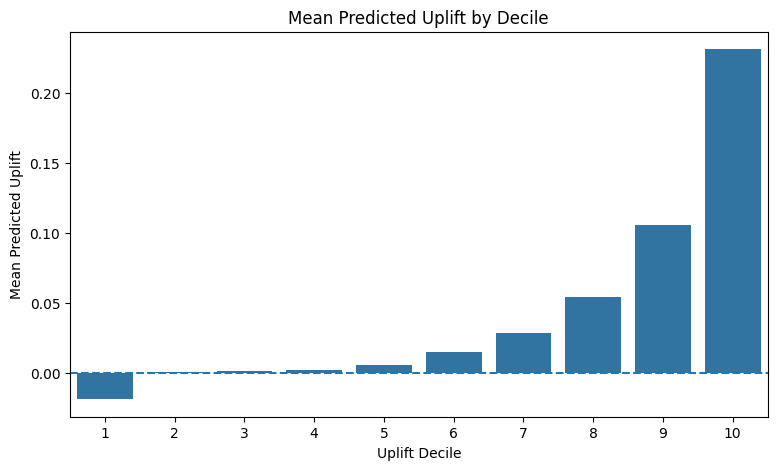

In [12]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=decile_summary.reset_index(),
    x="decile",
    y="mean_uplift"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title(
    "Mean Predicted Uplift by Decile"
)

plt.xlabel(
    "Uplift Decile"
)

plt.ylabel(
    "Mean Predicted Uplift"
)

plt.show()

In [13]:
top10_n = int(
    len(uplift_ranked) * 0.10
)

top10 = uplift_ranked.iloc[
    :top10_n
].copy()

uplift_at_10 = (
    top10["uplift"].mean()
)

print(
    f"Uplift@10%: {uplift_at_10:.6f}"
)

Uplift@10%: 0.231438


In [14]:
top20_n = int(
    len(uplift_ranked) * 0.20
)

top20 = uplift_ranked.iloc[
    :top20_n
].copy()

uplift_at_20 = (
    top20["uplift"].mean()
)

print(
    f"Uplift@20%: {uplift_at_20:.6f}"
)

Uplift@20%: 0.168556


In [15]:
uplift_ranked["cumulative_predicted_uplift"] = (
    uplift_ranked["uplift"]
    .cumsum()
)

uplift_ranked[
    [
        "rank",
        "population_fraction",
        "uplift",
        "cumulative_predicted_uplift"
    ]
].head(20)

,rank,population_fraction,uplift,cumulative_predicted_uplift
0,1,0.00005,0.747002,0.747002
1,2,0.00010,0.697850,1.444852
2,3,0.00015,0.635583,2.080435
3,4,0.00020,0.629903,2.710337
4,5,0.00025,0.629509,3.339846
5,6,0.00030,0.624729,3.964575
6,7,0.00035,0.624478,4.589053
7,8,0.00040,0.621858,5.210911
8,9,0.00045,0.614912,5.825823
9,10,0.00050,0.593734,6.419557


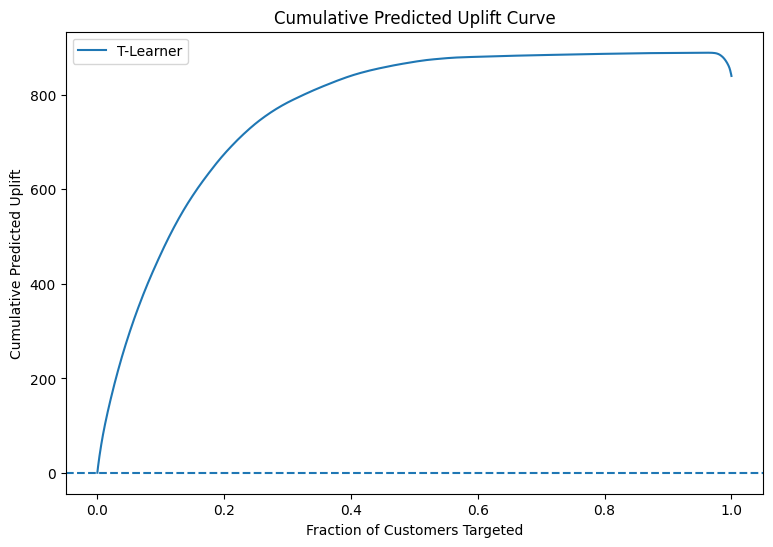

In [16]:
plt.figure(figsize=(9, 6))

plt.plot(
    uplift_ranked["population_fraction"],
    uplift_ranked["cumulative_predicted_uplift"],
    label="T-Learner"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Fraction of Customers Targeted"
)

plt.ylabel(
    "Cumulative Predicted Uplift"
)

plt.title(
    "Cumulative Predicted Uplift Curve"
)

plt.legend()

plt.show()

In [17]:
def calculate_qini_curve(
    data,
    treatment_col="actual_treatment",
    outcome_col="actual_conversion"
):
    
    n_treatment = (
        data[treatment_col] == 1
    ).sum()
    
    n_control = (
        data[treatment_col] == 0
    ).sum()
    
    treatment_outcomes = (
        data[treatment_col] *
        data[outcome_col]
    ).cumsum()
    
    control_outcomes = (
        ((1 - data[treatment_col]) *
         data[outcome_col])
        .cumsum()
    )
    
    treatment_count = (
        data[treatment_col]
        .cumsum()
    )
    
    control_count = (
        (1 - data[treatment_col])
        .cumsum()
    )
    
    treatment_rate = (
        treatment_outcomes /
        treatment_count.replace(0, np.nan)
    )
    
    control_rate = (
        control_outcomes /
        control_count.replace(0, np.nan)
    )
    
    qini = (
        treatment_outcomes -
        control_outcomes *
        (treatment_count /
         control_count.replace(0, np.nan))
    )
    
    return qini.fillna(0)

In [18]:
qini_curve = calculate_qini_curve(
    uplift_ranked
)

uplift_ranked["qini"] = qini_curve

uplift_ranked[
    [
        "rank",
        "population_fraction",
        "qini"
    ]
].head(20)

,rank,population_fraction,qini
0,1,0.00005,0.0
1,2,0.00010,0.0
2,3,0.00015,0.0
3,4,0.00020,0.0
4,5,0.00025,0.0
5,6,0.00030,0.0
6,7,0.00035,0.0
7,8,0.00040,0.0
8,9,0.00045,0.0
9,10,0.00050,0.0


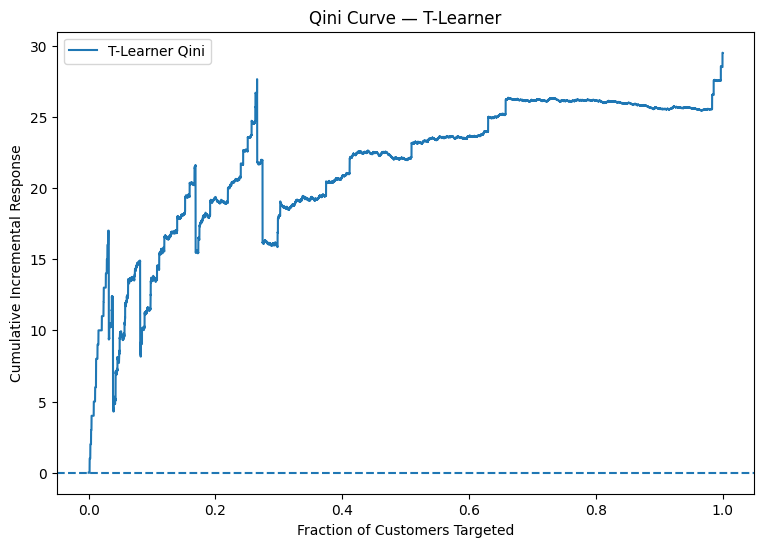

In [19]:
plt.figure(figsize=(9, 6))

plt.plot(
    uplift_ranked["population_fraction"],
    uplift_ranked["qini"],
    label="T-Learner Qini"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Fraction of Customers Targeted"
)

plt.ylabel(
    "Cumulative Incremental Response"
)

plt.title(
    "Qini Curve — T-Learner"
)

plt.legend()

plt.show()

In [20]:
qini_coefficient = np.trapezoid(
    uplift_ranked["qini"],
    uplift_ranked["population_fraction"]
)

print(
    f"Qini coefficient: {qini_coefficient:.6f}"
)

Qini coefficient: 21.562133


In [21]:
auuc = np.trapezoid(
    uplift_ranked["cumulative_predicted_uplift"],
    uplift_ranked["population_fraction"]
)

print(
    f"AUUC: {auuc:.6f}"
)

AUUC: 767.701027


In [22]:
random_fraction = np.linspace(
    0,
    1,
    len(uplift_ranked)
)

random_qini = (
    observed_ate *
    random_fraction *
    len(uplift_ranked)
)

random_qini[:10]

array([0.        , 0.00173842, 0.00347684, 0.00521526, 0.00695368,
       0.00869209, 0.01043051, 0.01216893, 0.01390735, 0.01564577])

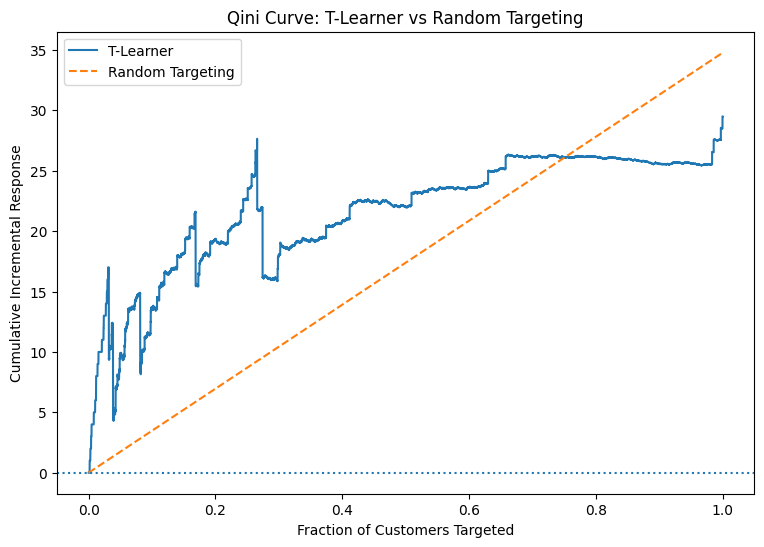

In [23]:
plt.figure(figsize=(9, 6))

plt.plot(
    uplift_ranked["population_fraction"],
    uplift_ranked["qini"],
    label="T-Learner"
)

plt.plot(
    random_fraction,
    random_qini,
    linestyle="--",
    label="Random Targeting"
)

plt.axhline(
    0,
    linestyle=":"
)

plt.xlabel(
    "Fraction of Customers Targeted"
)

plt.ylabel(
    "Cumulative Incremental Response"
)

plt.title(
    "Qini Curve: T-Learner vs Random Targeting"
)

plt.legend()

plt.show()

In [24]:
targeting_levels = [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    1.00
]

targeting_results = []

for level in targeting_levels:
    
    n = int(
        len(uplift_ranked) * level
    )
    
    selected = uplift_ranked.iloc[:n]
    
    targeting_results.append({
        "target_fraction": level,
        "customers_targeted": n,
        "mean_predicted_uplift": selected["uplift"].mean(),
        "total_predicted_uplift": selected["uplift"].sum()
    })

targeting_results = pd.DataFrame(
    targeting_results
)

targeting_results

,target_fraction,customers_targeted,mean_predicted_uplift,total_predicted_uplift
0,0.1,2000,0.231438,462.876922
1,0.2,4000,0.168556,674.224305
2,0.3,6000,0.130549,783.296783
3,0.4,8000,0.104979,839.830532
4,0.5,10000,0.086946,869.464487
5,1.0,20000,0.041975,839.492041


In [25]:
overall_mean_uplift = (
    uplift_ranked["uplift"].mean()
)

targeting_results["targeting_efficiency"] = (
    targeting_results["mean_predicted_uplift"] /
    overall_mean_uplift
)

targeting_results

,target_fraction,customers_targeted,mean_predicted_uplift,total_predicted_uplift,targeting_efficiency
0,0.1,2000,0.231438,462.876922,5.513774
1,0.2,4000,0.168556,674.224305,4.015668
2,0.3,6000,0.130549,783.296783,3.110201
3,0.4,8000,0.104979,839.830532,2.501008
4,0.5,10000,0.086946,869.464487,2.071406
5,1.0,20000,0.041975,839.492041,1.000000


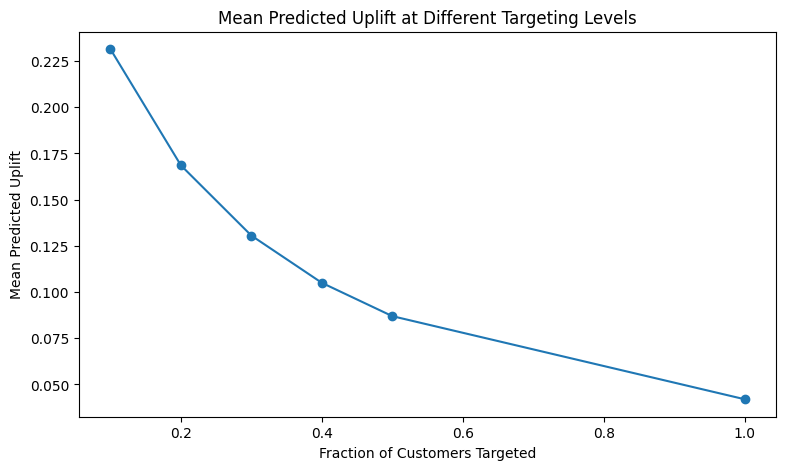

In [26]:
plt.figure(figsize=(9, 5))

plt.plot(
    targeting_results["target_fraction"],
    targeting_results["mean_predicted_uplift"],
    marker="o"
)

plt.xlabel(
    "Fraction of Customers Targeted"
)

plt.ylabel(
    "Mean Predicted Uplift"
)

plt.title(
    "Mean Predicted Uplift at Different Targeting Levels"
)

plt.show()

In [27]:
uplift_ranked[
    [
        "customer_index",
        "predicted_control",
        "predicted_treatment",
        "uplift",
        "actual_treatment",
        "actual_conversion"
    ]
].head(25)

,customer_index,predicted_control,predicted_treatment,uplift,actual_treatment,actual_conversion
0,99343,0.123074,0.870076,0.747002,1,0
1,74161,0.113354,0.811204,0.697850,0,0
2,58759,0.052978,0.688561,0.635583,1,0
3,96475,0.083911,0.713814,0.629903,1,0
4,68151,0.123849,0.753358,0.629509,1,0
5,31892,0.078600,0.703329,0.624729,1,0
6,86056,0.075880,0.700358,0.624478,1,0
7,58131,0.187960,0.809818,0.621858,1,0
8,66408,0.162315,0.777227,0.614912,1,0
9,11654,0.055588,0.649322,0.593734,0,0


In [28]:
uplift_ranked[
    [
        "customer_index",
        "predicted_control",
        "predicted_treatment",
        "uplift",
        "actual_treatment",
        "actual_conversion"
    ]
].tail(25)

,customer_index,predicted_control,predicted_treatment,uplift,actual_treatment,actual_conversion
19975,36532,0.571239,0.289747,-0.281492,1,0
19976,39333,0.529844,0.242599,-0.287245,1,0
19977,15389,0.443334,0.152586,-0.290748,1,0
19978,87978,0.531597,0.240284,-0.291313,1,0
19979,20719,0.327498,0.032106,-0.295393,1,0
19980,38353,0.381174,0.084991,-0.296183,1,0
19981,8312,0.337283,0.040511,-0.296772,0,0
19982,6941,0.708614,0.411521,-0.297093,1,0
19983,84409,0.403885,0.106063,-0.297822,1,0
19984,61128,0.557573,0.253490,-0.304083,1,0


In [29]:
evaluation_summary = pd.DataFrame({
    "metric": [
        "Test customers",
        "Observed treatment effect",
        "Mean predicted uplift",
        "Median predicted uplift",
        "Uplift@10%",
        "Uplift@20%",
        "Qini coefficient",
        "AUUC"
    ],
    "value": [
        len(uplift_ranked),
        observed_ate,
        uplift_ranked["uplift"].mean(),
        uplift_ranked["uplift"].median(),
        uplift_at_10,
        uplift_at_20,
        qini_coefficient,
        auuc
    ]
})

evaluation_summary

,metric,value
0,Test customers,20000.000000
1,Observed treatment effect,0.001738
2,Mean predicted uplift,0.041975
3,Median predicted uplift,0.010399
4,Uplift@10%,0.231438
5,Uplift@20%,0.168556
6,Qini coefficient,21.562133
7,AUUC,767.701027


In [30]:
OUTPUT_DIR = Path(
    r"C:\Users\ugand\customer-churn-uplift-modeling\data\processed"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

evaluation_summary_path = (
    OUTPUT_DIR /
    "uplift_evaluation_summary.csv"
)

evaluation_summary.to_csv(
    evaluation_summary_path,
    index=False
)

print(
    "Evaluation summary saved to:"
)

print(
    evaluation_summary_path
)

Evaluation summary saved to:
C:\Users\ugand\customer-churn-uplift-modeling\data\processed\uplift_evaluation_summary.csv


In [31]:
decile_output_path = (
    OUTPUT_DIR /
    "uplift_decile_analysis.csv"
)

decile_summary.to_csv(
    decile_output_path
)

print(
    "Decile analysis saved to:"
)

print(
    decile_output_path
)

Decile analysis saved to:
C:\Users\ugand\customer-churn-uplift-modeling\data\processed\uplift_decile_analysis.csv


In [32]:
ranked_output_path = (
    OUTPUT_DIR /
    "ranked_uplift_customers.csv"
)

uplift_ranked.to_csv(
    ranked_output_path,
    index=False
)

print(
    "Ranked uplift predictions saved to:"
)

print(
    ranked_output_path
)

Ranked uplift predictions saved to:
C:\Users\ugand\customer-churn-uplift-modeling\data\processed\ranked_uplift_customers.csv


## 31. Interpretation

The uplift evaluation should focus on whether customers with higher predicted uplift demonstrate stronger incremental treatment response.

Important indicators include:

- Positive Uplift@10%
- Positive Uplift@20%
- Strong concentration of uplift in the highest-ranked customers
- A Qini curve that improves over random targeting
- A positive Qini coefficient
- A positive AUUC

The model should not be judged using conventional accuracy alone because uplift modeling evaluates treatment-effect ranking rather than simple outcome prediction.

# Conclusion

## Uplift Model Evaluation Summary

This notebook evaluated the T-Learner using uplift-specific evaluation methods.

The evaluation focused on whether the model successfully ranks customers according to their expected incremental response to treatment.

### Metrics Evaluated

- Uplift@10%
- Uplift@20%
- Cumulative predicted uplift
- Qini Curve
- Qini Coefficient
- Area Under the Uplift Curve (AUUC)
- Targeting efficiency
- Random targeting benchmark

### Key Findings

The T-Learner produced customer-level uplift estimates that can be used to prioritize customers for treatment.

The uplift ranking provides a framework for identifying customers who are predicted to receive greater incremental benefit from treatment.

The highest-ranked customers represent the most promising treatment targets, while customers with low or negative predicted uplift may be lower-priority targets.

### Business Interpretation

The evaluation moves the project beyond conventional conversion prediction.

Instead of asking:

> Who is likely to convert?

the model evaluation asks:

> Who should receive treatment to maximize incremental conversions?

This allows marketing resources to be concentrated on customers with the greatest expected incremental response.

### Important Limitation

Because individual counterfactual outcomes cannot simultaneously be observed for the same customer, individual uplift predictions cannot be directly verified from a single observation.

The randomized treatment structure allows aggregate treatment effects to be estimated, while uplift curves and related metrics evaluate the quality of the model's ranking.

Therefore, Qini, AUUC, and uplift-at-k should be interpreted as evaluation tools for treatment prioritization rather than direct measurements of each individual's true causal effect.

### Next Notebook

**08 — Uplift Model Comparison**

The next stage will compare multiple uplift approaches, including:

- T-Learner
- S-Learner
- X-Learner

The models will be evaluated using the same uplift metrics so that their treatment-ranking performance can be compared consistently.